# Phase 5 — Error Analysis & Ablation Study

**Description:**
Phân tích định tính lỗi của mô hình ViT5-base (best case / worst case), phân loại các nhóm lỗi (hallucination, length mismatch), thực hiện ablation study so sánh greedy decoding và beam search, đồng thời vẽ biểu đồ learning curve từ lịch sử huấn luyện.

**Outputs:**
- Các file CSV phân tích lỗi lưu tại `results/error_analysis/`
- Hình ảnh biểu đồ `learning_curve_vit5.png`

## Cell 1 — Setup & Install Dependencies

In [9]:
import os, sys
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate

# ── Detect platform & Mount Drive ──
ON_KAGGLE = os.path.exists("/kaggle")
ON_COLAB  = "google.colab" in sys.modules or os.path.exists("/content")

if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = "/content/drive/MyDrive/vimedaq-project"
elif ON_KAGGLE:
    DRIVE_ROOT = "/kaggle/working"
else:
    DRIVE_ROOT = ".."

print(f"Drive root set to: {DRIVE_ROOT}")

# Install dependencies (quietly)
!pip install transformers==4.46.3 evaluate rouge-score sacrebleu bert-score sentencepiece pyvi matplotlib seaborn pandas numpy -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root set to: /content/drive/MyDrive/vimedaq-project


## Cell 2 — Load Evaluation Results

In [2]:
# Load results from Phase 4
eval_vit5_path = os.path.join(DRIVE_ROOT, "results", "eval_vit5.json")
if not os.path.exists(eval_vit5_path):
    raise FileNotFoundError(f"{eval_vit5_path} not found. Please run Phase 4 first.")

with open(eval_vit5_path, "r", encoding="utf-8") as f:
    eval_vit5_data = json.load(f)

df_eval = pd.DataFrame(eval_vit5_data)
print(f"Loaded {len(df_eval)} predictions from ViT5.")
display(df_eval.head(3))

Loaded 2348 predictions from ViT5.


,question,reference,prediction,topic
0,Bèo cái thu hái vào thời điểm nào là tốt nhất?,Thời điểm thu hái Bèo cái tốt nhất là vào mùa hè.,Thời điểm tốt nhất để thu hái bèo cái là vào m...,3
1,Khi nào nổi hạch ở hàm dưới có thể là dấu hiệu...,Khi nổi hạch ở hàm dưới kèm theo các biểu hiện...,Nổi hạch ở hàm dưới có thể là dấu hiệu gợi ý u...,1
2,Didicera dùng theo đường nào?,Didicera dùng theo đường uống.,Didicera dùng đường uống.,2


## Cell 3 — Best Case / Worst Case Analysis

In [3]:
rouge = evaluate.load("rouge")

print("Tính điểm ROUGE-L cho từng câu...")
rougeL_scores = []
for idx, row in df_eval.iterrows():
    r = rouge.compute(predictions=[row['prediction']], references=[row['reference']])
    rougeL_scores.append(r['rougeL'])

df_eval['rougeL'] = rougeL_scores

# Sắp xếp và lấy top/bottom 10
df_eval_sorted = df_eval.sort_values(by="rougeL", ascending=False)
best_cases = df_eval_sorted.head(10)
worst_cases = df_eval_sorted.tail(10)

out_dir = os.path.join(DRIVE_ROOT, "results", "error_analysis")
os.makedirs(out_dir, exist_ok=True)
best_cases.to_csv(os.path.join(out_dir, "best_10_cases.csv"), index=False)
worst_cases.to_csv(os.path.join(out_dir, "worst_10_cases.csv"), index=False)
print(f"Saved best and worst cases to: {out_dir}")

Tính điểm ROUGE-L cho từng câu...
Saved best and worst cases to: /content/drive/MyDrive/vimedaq-project/results/error_analysis


## Cell 4 — Display Best/Worst Cases for Manual Inspection

In [4]:
print("=== TOP 3 BEST CASES ===")
for i, row in best_cases.head(3).iterrows():
    print(f"Topic: {row['topic']} | ROUGE-L: {row['rougeL']:.4f}")
    print(f"Q: {row['question']}")
    print(f"Ref : {row['reference']}")
    print(f"Pred: {row['prediction']}")
    print("-" * 80)

print("\n=== TOP 3 WORST CASES ===")
for i, row in worst_cases.head(3).iterrows():
    print(f"Topic: {row['topic']} | ROUGE-L: {row['rougeL']:.4f}")
    print(f"Q: {row['question']}")
    print(f"Ref : {row['reference']}")
    print(f"Pred: {row['prediction']}")
    print("-" * 80)

print("\n(Phân tích định tính: Dựa vào các file CSV, người nghiên cứu có thể phân tích sâu hơn về Failure Mode)")

=== TOP 3 BEST CASES ===
Topic: 2 | ROUGE-L: 1.0000
Q: Có nghiên cứu nào về tác động của thuốc Anaferon đối với người lái tàu xe hay vận hành máy móc không?
Ref : Chưa có nghiên cứu nào về tác động của thuốc Anaferon đối với người lái tàu xe hay vận hành máy móc.
Pred: Chưa có nghiên cứu nào về tác động của thuốc Anaferon đối với người lái tàu xe hay vận hành máy móc.
--------------------------------------------------------------------------------
Topic: 2 | ROUGE-L: 1.0000
Q: Phải làm gì trước khi sử dụng thuốc Artreil nếu bạn là phụ nữ có thai hoặc đang cho con bú?
Ref : Hỏi ý kiến của bác sĩ trước khi dùng thuốc.
Pred: Hỏi ý kiến của bác sĩ trước khi dùng thuốc.
--------------------------------------------------------------------------------
Topic: 3 | ROUGE-L: 1.0000
Q: Theo Y học cổ truyền, ngó sen có tính gì?
Ref : Theo Y học cổ truyền, ngó sen có tính mát, bình, không có độc.
Pred: Theo Y học cổ truyền, ngó sen có tính mát, bình, không có độc.
-----------------------------------

## Cell 5 — Failure Mode Categorization (Heuristics)

In [5]:
# Tính toán độ lệch chiều dài (Length Mismatch)
df_eval['ref_len'] = df_eval['reference'].apply(lambda x: len(x.split()))
df_eval['pred_len'] = df_eval['prediction'].apply(lambda x: len(x.split()))
df_eval['len_ratio'] = df_eval['pred_len'] / (df_eval['ref_len'] + 1e-9)

# Heuristic: Nếu độ dài câu dự đoán < 50% hoặc > 200% so với reference -> Có thể coi là Length Mismatch
length_mismatch = df_eval[(df_eval['len_ratio'] < 0.5) | (df_eval['len_ratio'] > 2.0)]

print("=== FAILURE MODE ANALYSIS (HEURISTICS) ===")
print(f"Total evaluated: {len(df_eval)}")
print(f"Potential Length Mismatch: {len(length_mismatch)} samples ({(len(length_mismatch)/len(df_eval))*100:.2f}%)")

# Lưu lại các trường hợp length mismatch để làm minh chứng trong báo cáo
length_mismatch.to_csv(os.path.join(out_dir, "length_mismatch_cases.csv"), index=False)

print("Các lỗi Factual Hallucination và Topic Confusion cần được review thủ công từ file worst_10_cases.csv.")

=== FAILURE MODE ANALYSIS (HEURISTICS) ===
Total evaluated: 2348
Potential Length Mismatch: 377 samples (16.06%)
Các lỗi Factual Hallucination và Topic Confusion cần được review thủ công từ file worst_10_cases.csv.


## Cell 6 — Ablation Study (Beam Search vs Greedy Decoding)

Kiểm chứng sự ảnh hưởng của kỹ thuật giải mã trên tập Validation.

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
vit5_path = os.path.join(DRIVE_ROOT, "checkpoints", "vit5", "best")
val_path = os.path.join(DRIVE_ROOT, "data", "processed", "val.json")

if not os.path.exists(vit5_path) or not os.path.exists(val_path):
    print("Warning: Không tìm thấy model hoặc tập validation. Bỏ qua Ablation.")
else:
    print(f"Loading ViT5 from {vit5_path}...")
    tokenizer = AutoTokenizer.from_pretrained(vit5_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(vit5_path).to(device)

    with open(val_path, "r", encoding="utf-8") as f:
        val_data = json.load(f)

    val_q = [d['question'] for d in val_data]
    val_c = [d['context'] for d in val_data]
    val_ref = [d['answer'] for d in val_data]

    def run_inference(beams):
        preds = []
        batch_size = 8
        model.eval()
        for i in tqdm(range(0, len(val_q), batch_size), desc=f"Inference beams={beams}"):
            batch_q = val_q[i:i+batch_size]
            batch_c = val_c[i:i+batch_size]
            inputs_text = [f"question: {q} context: {c}" for q, c in zip(batch_q, batch_c)]
            inputs = tokenizer(inputs_text, return_tensors="pt", max_length=512, padding=True, truncation=True).to(device)
            with torch.no_grad():
                outputs = model.generate(**inputs, max_length=128, num_beams=beams, early_stopping=(beams>1))
            preds.extend([p.strip() for p in tokenizer.batch_decode(outputs, skip_special_tokens=True)])
        return preds

    print("\nRunning Greedy Decoding (num_beams=1)...")
    preds_greedy = run_inference(1)

    print("Running Beam Search (num_beams=4)...")
    preds_beam = run_inference(4)

    r_greedy = rouge.compute(predictions=preds_greedy, references=val_ref)
    r_beam = rouge.compute(predictions=preds_beam, references=val_ref)

    ablation_res = pd.DataFrame([
        {"Decoding": "Greedy (beams=1)", "ROUGE-1": round(r_greedy['rouge1'], 4), "ROUGE-2": round(r_greedy['rouge2'], 4), "ROUGE-L": round(r_greedy['rougeL'], 4)},
        {"Decoding": "Beam Search (beams=4)", "ROUGE-1": round(r_beam['rouge1'], 4), "ROUGE-2": round(r_beam['rouge2'], 4), "ROUGE-L": round(r_beam['rougeL'], 4)}
    ])

    print("\n=== ABLATION STUDY RESULTS ===")
    print(ablation_res.to_string(index=False))
    ablation_res.to_csv(os.path.join(out_dir, "ablation_decoding.csv"), index=False)

    del model
    torch.cuda.empty_cache()

Loading ViT5 from /content/drive/MyDrive/vimedaq-project/checkpoints/vit5/best...


You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers



Running Greedy Decoding (num_beams=1)...


Inference beams=1: 100%|██████████| 295/295 [07:06<00:00,  1.45s/it]


Running Beam Search (num_beams=4)...


Inference beams=4: 100%|██████████| 295/295 [10:05<00:00,  2.05s/it]



=== ABLATION STUDY RESULTS ===
             Decoding  ROUGE-1  ROUGE-2  ROUGE-L
     Greedy (beams=1)   0.7188   0.5998   0.6527
Beam Search (beams=4)   0.7242   0.6069   0.6587


## Cell 7 — Learning Curve Plot

NameError: name 'out_dir' is not defined

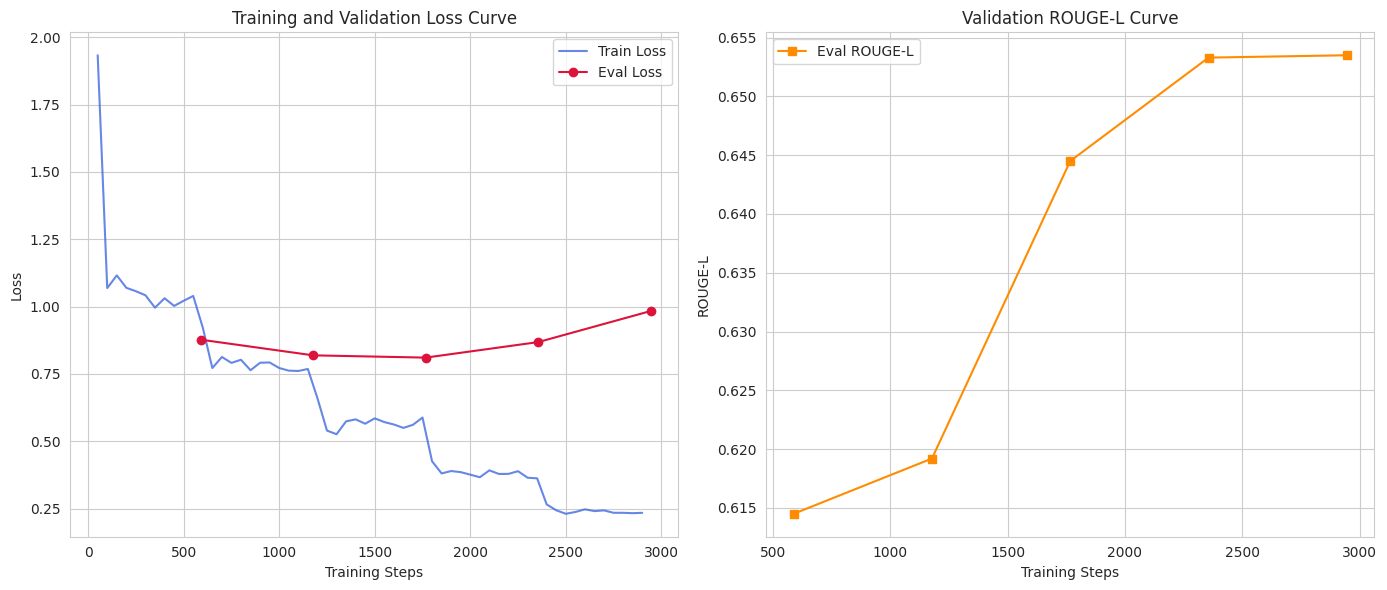

In [10]:
log_path = os.path.join(DRIVE_ROOT, "logs", "vit5_training_log.csv")
if os.path.exists(log_path):
    log_df = pd.read_csv(log_path)

    # Tách dữ liệu training và validation
    train_logs = log_df.dropna(subset=['loss', 'step']).copy()
    eval_logs = log_df.dropna(subset=['eval_loss', 'step']).copy()

    sns.set_style("whitegrid")
    plt.figure(figsize=(14, 6))

    # Plot 1: Train Loss & Eval Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_logs['step'], train_logs['loss'], label="Train Loss", color="royalblue", alpha=0.8)
    if not eval_logs.empty:
        plt.plot(eval_logs['step'], eval_logs['eval_loss'], label="Eval Loss", color="crimson", marker="o")
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Curve")
    plt.legend()

    # Plot 2: Eval ROUGE-L
    if not eval_logs.empty and 'eval_rougeL' in eval_logs.columns:
        plt.subplot(1, 2, 2)
        plt.plot(eval_logs['step'], eval_logs['eval_rougeL'], label="Eval ROUGE-L", color="darkorange", marker='s')
        plt.xlabel("Training Steps")
        plt.ylabel("ROUGE-L")
        plt.title("Validation ROUGE-L Curve")
        plt.legend()

    plt.tight_layout()
    plot_path = os.path.join(out_dir, "learning_curve_vit5.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\nLearning curve plot saved to: {plot_path}")
else:
    print(f"Warning: Log file not found at {log_path}. Could not plot learning curve.")

print("\nPhase 5 is complete!")